In [2]:
# libraries and project folders
import pandas as pd
import numpy as np
import pyodbc
import matplotlib.pyplot as plt

from pathlib import Path
from getpass import getpass
from urllib.parse import quote_plus
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from sqlalchemy import create_engine, text

project_folder = Path.cwd()

if project_folder.name == "notebooks":
    project_folder = project_folder.parent

docs_folder = project_folder / "docs"
docs_folder.mkdir(exist_ok=True)

print("Project folder:", project_folder)

Project folder: c:\Users\naren\OneDrive\Desktop\Data Analytics\Projects\Portfolio Centerpiece Projects using AI\end-to-end-google-product-analytics-platform


In [5]:
# Azure SQL connection
driver = "ODBC Driver 18 for SQL Server"

if driver not in pyodbc.drivers():
    print("Install ODBC Driver 18 for SQL Server first.")
    print("Available drivers:", pyodbc.drivers())
    raise SystemExit

server = input(
    "Server name, example tcp:yourserver.database.windows.net,1433: "
).strip()

database = input("Database name: ").strip()
username = input("Username: ").strip()
password = getpass("Password: ")

connection_string = (
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"UID={username};"
    f"PWD={password};"
    "Encrypt=yes;"
    "TrustServerCertificate=no;"
    "Connection Timeout=30;"
)

engine = create_engine(
    "mssql+pyodbc:///?odbc_connect="
    + quote_plus(connection_string)
)

with engine.connect() as connection:
    print(
        "Connected database:",
        connection.execute(text("select db_name()")).scalar()
    )

Connected database: google_product_analytics_db


In [7]:
# experiment users
assignment_query = '''
select
    e.experiment_id,
    e.user_key,
    u.user_id,
    e.variant,
    a.full_date as assignment_date,
    x.full_date as exposure_date,
    u.age_group,
    u.subscription_type,
    u.acquisition_channel
from analytics.fact_experiments e
join analytics.dim_user u
    on e.user_key = u.user_key
join analytics.dim_date a
    on e.assignment_date_key = a.date_key
left join analytics.dim_date x
    on e.exposure_date_key = x.date_key
where e.eligible_flag = 1
'''

assignments = pd.read_sql(assignment_query, engine)

assignments["assignment_date"] = pd.to_datetime(
    assignments["assignment_date"]
)

assignments["exposure_date"] = pd.to_datetime(
    assignments["exposure_date"]
)

print("Experiment users:", len(assignments))
display(assignments.head())

Experiment users: 11855


,experiment_id,user_key,user_id,variant,assignment_date,exposure_date,age_group,subscription_type,acquisition_channel
0,EXP_2026_HOMEPAGE_RANK_V2,1,U000001,Treatment,2026-06-23,2026-06-25,13-17,Free,Pre-installed App
1,EXP_2026_HOMEPAGE_RANK_V2,2,U000002,Control,2026-05-18,2026-05-19,25-34,Free,Direct
2,EXP_2026_HOMEPAGE_RANK_V2,4,U000004,Treatment,2026-04-20,2026-04-21,18-24,Free,Direct
3,EXP_2026_HOMEPAGE_RANK_V2,5,U000005,Treatment,2026-06-26,2026-06-28,25-34,YouTube Premium,Social Media
4,EXP_2026_HOMEPAGE_RANK_V2,9,U000009,Treatment,2026-06-11,2026-06-15,35-44,Premium Trial,Pre-installed App


In [8]:
# assignment checks
variant_counts = assignments["variant"].value_counts()
variant_share = (
    variant_counts / variant_counts.sum() * 100
).round(2)

users_in_many_variants = (
    assignments.groupby("user_key")["variant"]
    .nunique()
    .gt(1)
    .sum()
)

missing_exposure_dates = assignments["exposure_date"].isna().sum()

invalid_exposure_dates = (
    assignments["exposure_date"]
    < assignments["assignment_date"]
).sum()

print("Users by variant")
display(pd.DataFrame({
    "users": variant_counts,
    "share_percent": variant_share
}))

print("Users in more than one variant:", users_in_many_variants)
print("Missing exposure dates:", missing_exposure_dates)
print("Exposure before assignment:", invalid_exposure_dates)

print("Age-group mix")
display(
    pd.crosstab(
        assignments["variant"],
        assignments["age_group"],
        normalize="index"
    ).mul(100).round(2)
)

print("Subscription mix")
display(
    pd.crosstab(
        assignments["variant"],
        assignments["subscription_type"],
        normalize="index"
    ).mul(100).round(2)
)

print("Acquisition mix")
display(
    pd.crosstab(
        assignments["variant"],
        assignments["acquisition_channel"],
        normalize="index"
    ).mul(100).round(2)
)

Users by variant


,users,share_percent
variant,,
Control,5939,50.1
Treatment,5916,49.9


Users in more than one variant: 0
Missing exposure dates: 0
Exposure before assignment: 0
Age-group mix


age_group,13-17,18-24,25-34,35-44,45-54,55-64,65+
variant,,,,,,,
Control,4.63,28.85,30.21,17.95,9.77,5.38,3.21
Treatment,5.05,27.72,30.81,17.40,9.99,6.03,3.01


Subscription mix


subscription_type,Free,Premium Trial,YouTube Premium
variant,,,
Control,77.94,7.21,14.85
Treatment,78.48,7.00,14.52


Acquisition mix


acquisition_channel,Direct,Google Ads,Organic Search,Pre-installed App,Referral,Social Media
variant,,,,,,
Control,8.27,15.24,29.97,11.60,10.20,24.72
Treatment,8.06,14.76,30.27,11.46,10.18,25.27


In [9]:
# sessions and events around the experiment
session_query = '''
select
    s.session_id,
    s.user_key,
    e.variant,
    d.full_date as session_date,
    x.full_date as exposure_date,
    s.session_duration_minutes
from analytics.fact_sessions s
join analytics.fact_experiments e
    on s.user_key = e.user_key
join analytics.dim_date d
    on s.date_key = d.date_key
join analytics.dim_date x
    on e.exposure_date_key = x.date_key
where e.eligible_flag = 1
  and d.full_date between dateadd(day, -7, x.full_date)
                      and dateadd(day, 13, x.full_date)
'''

event_query = '''
select
    f.event_id,
    f.session_id,
    f.user_key,
    e.variant,
    d.full_date as event_date,
    x.full_date as exposure_date,
    f.event_name,
    f.video_key,
    f.watch_duration_seconds
from analytics.fact_events f
join analytics.fact_experiments e
    on f.user_key = e.user_key
join analytics.dim_date d
    on f.date_key = d.date_key
join analytics.dim_date x
    on e.exposure_date_key = x.date_key
where e.eligible_flag = 1
  and d.full_date between dateadd(day, -7, x.full_date)
                      and dateadd(day, 13, x.full_date)
'''

sessions = pd.read_sql(session_query, engine)
events = pd.read_sql(event_query, engine)

sessions["session_date"] = pd.to_datetime(sessions["session_date"])
sessions["exposure_date"] = pd.to_datetime(sessions["exposure_date"])

events["event_date"] = pd.to_datetime(events["event_date"])
events["exposure_date"] = pd.to_datetime(events["exposure_date"])

sessions["session_duration_minutes"] = pd.to_numeric(
    sessions["session_duration_minutes"],
    errors="coerce"
)

events["watch_duration_seconds"] = pd.to_numeric(
    events["watch_duration_seconds"],
    errors="coerce"
).fillna(0)

sessions["day_from_exposure"] = (
    sessions["session_date"] - sessions["exposure_date"]
).dt.days

events["day_from_exposure"] = (
    events["event_date"] - events["exposure_date"]
).dt.days

print("Sessions loaded:", len(sessions))
print("Events loaded:", len(events))

Sessions loaded: 7062
Events loaded: 52798


In [10]:
# pre-experiment behaviour
pre_sessions = sessions[
    sessions["day_from_exposure"].between(-7, -1)
].copy()

pre_events = events[
    events["day_from_exposure"].between(-7, -1)
].copy()

pre_session_count = (
    pre_sessions.groupby("user_key")["session_id"]
    .nunique()
    .rename("pre_sessions")
)

pre_video_events = pre_events[
    pre_events["video_key"].notna()
].copy()

pre_video_views = (
    pre_video_events.groupby(
        ["user_key", "session_id", "video_key"]
    )["watch_duration_seconds"]
    .max()
    .fillna(0)
)

pre_watch_time = (
    pre_video_views.groupby("user_key")
    .sum()
    .div(60)
    .rename("pre_watch_minutes")
)

pre_check = assignments[
    ["user_key", "variant"]
].merge(
    pre_session_count,
    on="user_key",
    how="left"
).merge(
    pre_watch_time,
    on="user_key",
    how="left"
).fillna(0)

pre_results = []

for metric in ["pre_sessions", "pre_watch_minutes"]:
    control = pre_check.loc[
        pre_check["variant"] == "Control", metric
    ]

    treatment = pre_check.loc[
        pre_check["variant"] == "Treatment", metric
    ]

    p_value = ttest_ind(
        control,
        treatment,
        equal_var=False
    ).pvalue

    pre_results.append({
        "metric": metric,
        "control_mean": control.mean(),
        "treatment_mean": treatment.mean(),
        "p_value": p_value
    })

pre_results = pd.DataFrame(pre_results).round(4)
display(pre_results)

,metric,control_mean,treatment_mean,p_value
0,pre_sessions,0.1960,0.1973,0.8914
1,pre_watch_minutes,0.7123,0.6469,0.4995


In [11]:
# user-level experiment metrics
post_sessions = sessions[
    sessions["day_from_exposure"].between(0, 13)
].copy()

post_events = events[
    events["day_from_exposure"].between(0, 13)
].copy()

user_metrics = assignments[
    ["user_key", "user_id", "variant"]
].copy()

session_summary = post_sessions.groupby("user_key").agg(
    total_sessions=("session_id", "nunique"),
    immediate_exit_sessions=(
        "session_duration_minutes",
        lambda x: (x < 1).sum()
    )
)

event_names = [
    "video_impression",
    "video_click",
    "video_start",
    "video_complete"
]

event_counts = pd.crosstab(
    post_events["user_key"],
    post_events["event_name"]
).reindex(
    columns=event_names,
    fill_value=0
)

video_events = post_events[
    post_events["video_key"].notna()
].copy()

video_events["started"] = (
    video_events["event_name"] == "video_start"
).astype(int)

video_events["completed"] = (
    video_events["event_name"] == "video_complete"
).astype(int)

video_events["engaged"] = video_events["event_name"].isin(
    ["like", "comment", "share", "subscribe_channel"]
).astype(int)

video_views = video_events.groupby(
    ["user_key", "session_id", "video_key"]
).agg(
    started=("started", "max"),
    completed=("completed", "max"),
    engaged=("engaged", "max"),
    watch_seconds=("watch_duration_seconds", "max")
).reset_index()

video_views["watch_seconds"] = (
    video_views["watch_seconds"].fillna(0)
)

video_views["very_short"] = (
    (video_views["started"] == 1)
    & (video_views["watch_seconds"] < 10)
).astype(int)

view_summary = video_views.groupby("user_key").agg(
    videos_watched=("started", "sum"),
    completed_videos=("completed", "sum"),
    engaged_videos=("engaged", "sum"),
    watch_seconds=("watch_seconds", "sum"),
    very_short_views=("very_short", "sum")
)

impressions = post_events[
    (post_events["event_name"] == "video_impression")
    & post_events["video_key"].notna()
].groupby(
    ["user_key", "session_id", "video_key"]
).size().rename("impression_count").reset_index()

repeat_summary = impressions.groupby("user_key").agg(
    impression_pairs=("impression_count", "size"),
    repeated_pairs=(
        "impression_count",
        lambda x: (x > 1).sum()
    )
)

day_7_users = set(
    post_sessions.loc[
        post_sessions["day_from_exposure"] == 7,
        "user_key"
    ]
)

user_metrics = user_metrics.merge(
    session_summary,
    on="user_key",
    how="left"
).merge(
    event_counts,
    on="user_key",
    how="left"
).merge(
    view_summary,
    on="user_key",
    how="left"
).merge(
    repeat_summary,
    on="user_key",
    how="left"
).fillna(0)

user_metrics["day_7_retained"] = (
    user_metrics["user_key"].isin(day_7_users)
).astype(int)

user_metrics["watch_minutes"] = (
    user_metrics["watch_seconds"] / 60
)

user_metrics["average_watch_minutes_per_session"] = np.where(
    user_metrics["total_sessions"] > 0,
    user_metrics["watch_minutes"]
    / user_metrics["total_sessions"],
    0
)

user_metrics["videos_per_session"] = np.where(
    user_metrics["total_sessions"] > 0,
    user_metrics["videos_watched"]
    / user_metrics["total_sessions"],
    0
)

print("User-level rows:", len(user_metrics))
display(user_metrics.head())

User-level rows: 11855


,user_key,user_id,variant,total_sessions,immediate_exit_sessions,video_impression,video_click,video_start,video_complete,videos_watched,completed_videos,engaged_videos,watch_seconds,very_short_views,impression_pairs,repeated_pairs,day_7_retained,watch_minutes,average_watch_minutes_per_session,videos_per_session
0,1,U000001,Treatment,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
1,2,U000002,Control,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
2,4,U000004,Treatment,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
3,5,U000005,Treatment,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
4,9,U000009,Treatment,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0


In [12]:
# statistical test functions
def mean_test(metric, label):
    control = user_metrics.loc[
        user_metrics["variant"] == "Control",
        metric
    ]

    treatment = user_metrics.loc[
        user_metrics["variant"] == "Treatment",
        metric
    ]

    control_mean = control.mean()
    treatment_mean = treatment.mean()
    difference = treatment_mean - control_mean

    standard_error = np.sqrt(
        control.var(ddof=1) / len(control)
        + treatment.var(ddof=1) / len(treatment)
    )

    p_value = ttest_ind(
        control,
        treatment,
        equal_var=False
    ).pvalue

    uplift = (
        difference / control_mean * 100
        if control_mean != 0
        else np.nan
    )

    return {
        "metric": label,
        "control": control_mean,
        "treatment": treatment_mean,
        "difference": difference,
        "uplift_percent": uplift,
        "ci_low": difference - 1.96 * standard_error,
        "ci_high": difference + 1.96 * standard_error,
        "p_value": p_value
    }


def proportion_test(success_column, total_column, label):
    group_data = user_metrics.groupby("variant")[
        [success_column, total_column]
    ].sum()

    control_success = group_data.loc[
        "Control", success_column
    ]

    control_total = group_data.loc[
        "Control", total_column
    ]

    treatment_success = group_data.loc[
        "Treatment", success_column
    ]

    treatment_total = group_data.loc[
        "Treatment", total_column
    ]

    control_rate = control_success / control_total
    treatment_rate = treatment_success / treatment_total
    difference = treatment_rate - control_rate

    standard_error = np.sqrt(
        control_rate * (1 - control_rate) / control_total
        + treatment_rate * (1 - treatment_rate) / treatment_total
    )

    p_value = proportions_ztest(
        [treatment_success, control_success],
        [treatment_total, control_total]
    )[1]

    uplift = (
        difference / control_rate * 100
        if control_rate != 0
        else np.nan
    )

    return {
        "metric": label,
        "control": control_rate * 100,
        "treatment": treatment_rate * 100,
        "difference": difference * 100,
        "uplift_percent": uplift,
        "ci_low": (difference - 1.96 * standard_error) * 100,
        "ci_high": (difference + 1.96 * standard_error) * 100,
        "p_value": p_value
    }

In [13]:
# comparing control and treatment
results = [
    mean_test(
        "average_watch_minutes_per_session",
        "Average Watch Time per Session"
    ),
    mean_test(
        "videos_per_session",
        "Videos Watched per Session"
    ),
    proportion_test(
        "video_click",
        "video_impression",
        "Impression CTR"
    ),
    proportion_test(
        "completed_videos",
        "videos_watched",
        "Video Completion Rate"
    ),
    proportion_test(
        "engaged_videos",
        "videos_watched",
        "Engagement Rate"
    ),
    proportion_test(
        "immediate_exit_sessions",
        "total_sessions",
        "Immediate Exit Rate"
    ),
    proportion_test(
        "very_short_views",
        "videos_watched",
        "Very Short View Rate"
    ),
    proportion_test(
        "repeated_pairs",
        "impression_pairs",
        "Repeated Recommendation Rate"
    )
]

day_7 = user_metrics.groupby("variant")["day_7_retained"].agg(
    ["sum", "count"]
)

control_rate = day_7.loc["Control", "sum"] / day_7.loc["Control", "count"]
treatment_rate = (
    day_7.loc["Treatment", "sum"]
    / day_7.loc["Treatment", "count"]
)

difference = treatment_rate - control_rate

standard_error = np.sqrt(
    control_rate * (1 - control_rate)
    / day_7.loc["Control", "count"]
    + treatment_rate * (1 - treatment_rate)
    / day_7.loc["Treatment", "count"]
)

p_value = proportions_ztest(
    [day_7.loc["Treatment", "sum"], day_7.loc["Control", "sum"]],
    [day_7.loc["Treatment", "count"], day_7.loc["Control", "count"]]
)[1]

results.append({
    "metric": "Seven-Day Retention",
    "control": control_rate * 100,
    "treatment": treatment_rate * 100,
    "difference": difference * 100,
    "uplift_percent": (
        difference / control_rate * 100
        if control_rate != 0
        else np.nan
    ),
    "ci_low": (difference - 1.96 * standard_error) * 100,
    "ci_high": (difference + 1.96 * standard_error) * 100,
    "p_value": p_value
})

results = pd.DataFrame(results).round(4)
display(results)

c:\Users\naren\anaconda3\Lib\site-packages\statsmodels\stats\weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


,metric,control,treatment,difference,uplift_percent,ci_low,ci_high,p_value
0,Average Watch Time per Session,1.0577,1.0409,-0.0167,-1.5833,-0.2674,0.2339,0.8958
1,Videos Watched per Session,0.1829,0.1576,-0.0253,-13.8343,-0.0425,-0.0081,0.0040
2,Impression CTR,40.0103,38.8411,-1.1692,-2.9222,-3.3858,1.0474,0.3013
3,Video Completion Rate,48.8651,54.5521,5.6870,11.6382,2.0829,9.2911,0.0020
4,Engagement Rate,29.2560,29.2790,0.0230,0.0785,-3.2644,3.3103,0.9891
5,Immediate Exit Rate,0.0416,0.0000,-0.0416,-100.0000,-0.1232,0.0399,0.3249
6,Very Short View Rate,12.5473,11.2163,-1.3310,-10.6077,-3.6642,1.0023,0.2653
7,Repeated Recommendation Rate,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,NaN
8,Seven-Day Retention,2.8288,2.6707,-0.1580,-5.5867,-0.7468,0.4307,0.5988


In [14]:
# practical significance and final decision
primary = results[
    results["metric"] == "Average Watch Time per Session"
].iloc[0]

guardrail_names = [
    "Immediate Exit Rate",
    "Very Short View Rate",
    "Repeated Recommendation Rate"
]

guardrails = results[
    results["metric"].isin(guardrail_names)
]

guardrail_harm = (
    (guardrails["difference"] > 1)
    & (guardrails["p_value"] < 0.05)
).any()

primary_is_significant = primary["p_value"] < 0.05
primary_is_practical = primary["uplift_percent"] >= 2

if (
    primary_is_significant
    and primary_is_practical
    and not guardrail_harm
):
    recommendation = (
        "Gradually launch the treatment and keep monitoring "
        "retention and recommendation quality."
    )
elif primary["difference"] > 0 and not guardrail_harm:
    recommendation = (
        "Continue the experiment because the result is positive, "
        "but the evidence is not strong enough for a full launch."
    )
else:
    recommendation = (
        "Do not launch the treatment yet. Review the recommendation "
        "logic and run another test."
    )

negative_feedback_events = {
    "dislike",
    "not_interested",
    "dont_recommend_channel",
    "negative_feedback"
}

negative_feedback_available = (
    post_events["event_name"]
    .isin(negative_feedback_events)
    .any()
)

print("Statistically significant:", primary_is_significant)
print("Practical uplift of at least 2%:", primary_is_practical)
print("Guardrail harm found:", guardrail_harm)
print("Negative feedback data available:", negative_feedback_available)
print("Recommendation:", recommendation)

Statistically significant: False
Practical uplift of at least 2%: False
Guardrail harm found: False
Negative feedback data available: False
Recommendation: Do not launch the treatment yet. Review the recommendation logic and run another test.


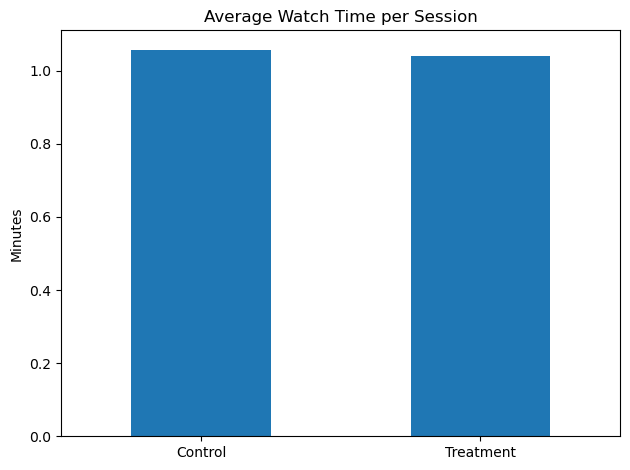

In [15]:
# primary metric chart
primary_chart = (
    user_metrics.groupby("variant")[
        "average_watch_minutes_per_session"
    ]
    .mean()
)

primary_chart.plot(
    kind="bar",
    title="Average Watch Time per Session"
)

plt.xlabel("")
plt.ylabel("Minutes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()